# Bayesian Optimization for Black-Box Functions

This notebook implements Gaussian Process-based Bayesian Optimization with Upper Confidence Bound (UCB) acquisition function.

## Strategy
- Iterations: 13 attempts total
- Acquisition: UCB with decreasing beta (exploration → exploitation)
- Beta schedule: Start at 2.5 (exploration), decay to 0.5 (exploitation)
- First ~7 iterations: High exploration
- Last ~6 iterations: More exploitation

## Workflow
1. Load initial data (already normalized to [0,1])
2. Set current iteration (1-13)
3. Generate predictions for all 8 functions
4. Submit and get actual outputs
5. Update dataset with new observations
6. Repeat


In [1]:
# Setup & Imports
import numpy as np
import re
import pandas as pd
from pathlib import Path
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


In [2]:
# Set current iteration

CURRENT_ITERATION = 13
TOTAL_ITERATIONS = 13

## 1. Load Initial Data


In [3]:
# Load initial data for all 8 functions
data_path = Path('../Data/InitialData')

# Store data for each function
functions_data = {}

for i in range(1, 9):
    func_name = f'function_{i}'
    func_path = data_path / func_name
    
    # Load inputs and outputs
    inputs = np.load(func_path / 'initial_inputs.npy')
    outputs = np.load(func_path / 'initial_outputs.npy')
    
    functions_data[func_name] = {
        'inputs': inputs.copy(),  # Store original inputs
        'outputs': outputs.copy(),  # Store original outputs
        'n_dims': inputs.shape[1],
        'input_min': inputs.min(axis=0),
        'input_max': inputs.max(axis=0),
        'best_output': outputs.max(),
        'best_input': inputs[outputs.argmax()]
    }
    
    print(f"{func_name}: {inputs.shape[0]} samples, {inputs.shape[1]}D, best={outputs.max():.4f}")

print(f"\n✓ Loaded data for {len(functions_data)} functions")


function_1: 10 samples, 2D, best=0.0000
function_2: 10 samples, 2D, best=0.6112
function_3: 15 samples, 3D, best=-0.0348
function_4: 30 samples, 4D, best=-4.0255
function_5: 20 samples, 4D, best=1088.8596
function_6: 20 samples, 5D, best=-0.7143
function_7: 30 samples, 6D, best=1.3650
function_8: 40 samples, 8D, best=9.5985

✓ Loaded data for 8 functions


In [4]:
# Load previous predictions and outputs (if they exist)
predictions_dir = Path('../Data/Predictions')

# Track initial sample counts for visualization later
for func_name in functions_data:
    functions_data[func_name]['initial_count'] = len(functions_data[func_name]['outputs'])

def parse_list_entries(file_content):
    """Parse a file containing multiple Python list entries (one per logical line).
    
    Handles arrays that wrap across multiple physical lines.
    Returns a list of parsed entries.
    """
    # Join all lines and normalize whitespace
    content = ' '.join(file_content.split())
    
    # Split on '] [' pattern (end of one list, start of next)
    # First, normalize the boundary pattern
    content = re.sub(r'\]\s*\[', ']\n[', content)
    
    entries = []
    for line in content.split('\n'):
        line = line.strip()
        if line:
            entries.append(line)
    
    return entries

iteration_pairs = []
if predictions_dir.exists():
    for input_file in predictions_dir.glob('inputs*.txt'):
        match = re.match(r'inputs(\d+)\.txt$', input_file.name)
        if not match:
            continue
        iter_num = int(match.group(1))
        # Only load iterations before the current iteration
        if iter_num >= CURRENT_ITERATION:
            continue
        output_file = predictions_dir / f'outputs{iter_num}.txt'
        if not output_file.exists():
            continue
        iteration_pairs.append((iter_num, input_file, output_file))

iteration_pairs.sort(key=lambda x: x[0])

if iteration_pairs:
    print("\n" + "="*80)
    print(f"LOADING PREVIOUS PREDICTIONS AND OUTPUTS (iterations 1 to {CURRENT_ITERATION - 1})")
    print("="*80 + "\n")

    eval_namespace = {'array': np.array, 'np': np}

    for iter_num, input_file, output_file in iteration_pairs:
        print(f"Iteration {iter_num}: loading {input_file.name} / {output_file.name}")

        with open(input_file, 'r') as f:
            inputs_content = f.read()
            input_entries = parse_list_entries(inputs_content)
            # Take the last entry (corresponds to this iteration's new data)
            inputs_str = input_entries[-1] if input_entries else inputs_content
            submitted_inputs = eval(inputs_str, {"__builtins__": {}}, eval_namespace)

        with open(output_file, 'r') as f:
            outputs_content = f.read()
            output_entries = parse_list_entries(outputs_content)
            # Take the last entry (corresponds to this iteration's new data)
            outputs_str = output_entries[-1] if output_entries else outputs_content
            actual_outputs = np.array(eval(outputs_str, {"__builtins__": {}}, eval_namespace))

        for i in range(8):
            func_name = f'function_{i+1}'
            next_point = submitted_inputs[i]
            actual_output = actual_outputs[i]

            functions_data[func_name]['inputs'] = np.vstack([
                functions_data[func_name]['inputs'],
                next_point
            ])
            functions_data[func_name]['outputs'] = np.append(
                functions_data[func_name]['outputs'],
                actual_output
            )

            all_outputs = functions_data[func_name]['outputs']
            best_idx = np.argmax(all_outputs)
            functions_data[func_name]['best_output'] = all_outputs[best_idx]
            functions_data[func_name]['best_input'] = functions_data[func_name]['inputs'][best_idx]

            print(f"  Function {i+1}: Added 1 observation, output={actual_output:.4f}, best={functions_data[func_name]['best_output']:.4f}")

        print()

    print("="*80)
    print(f"✓ Loaded {len(iteration_pairs)} previous iteration(s) into datasets")
    print("="*80)
else:
    print(f"(No previous predictions found for iterations 1 to {CURRENT_ITERATION - 1} - starting fresh)")



LOADING PREVIOUS PREDICTIONS AND OUTPUTS (iterations 1 to 12)

Iteration 1: loading inputs1.txt / outputs1.txt
  Function 1: Added 1 observation, output=-0.0000, best=0.0000
  Function 2: Added 1 observation, output=0.0781, best=0.6112
  Function 3: Added 1 observation, output=-0.1041, best=-0.0348
  Function 4: Added 1 observation, output=-0.8017, best=-0.8017
  Function 5: Added 1 observation, output=4697.3843, best=4697.3843
  Function 6: Added 1 observation, output=-0.8616, best=-0.7143
  Function 7: Added 1 observation, output=1.6448, best=1.6448
  Function 8: Added 1 observation, output=9.8548, best=9.8548

Iteration 2: loading inputs2.txt / outputs2.txt
  Function 1: Added 1 observation, output=0.0000, best=0.0000
  Function 2: Added 1 observation, output=0.0524, best=0.6112
  Function 3: Added 1 observation, output=-0.1194, best=-0.0348
  Function 4: Added 1 observation, output=-1.8473, best=-0.8017
  Function 5: Added 1 observation, output=5774.7956, best=5774.7956
  Function

## 2. Beta Strategy

Visualize how the exploration parameter (beta) decays over iterations for different dimensions.

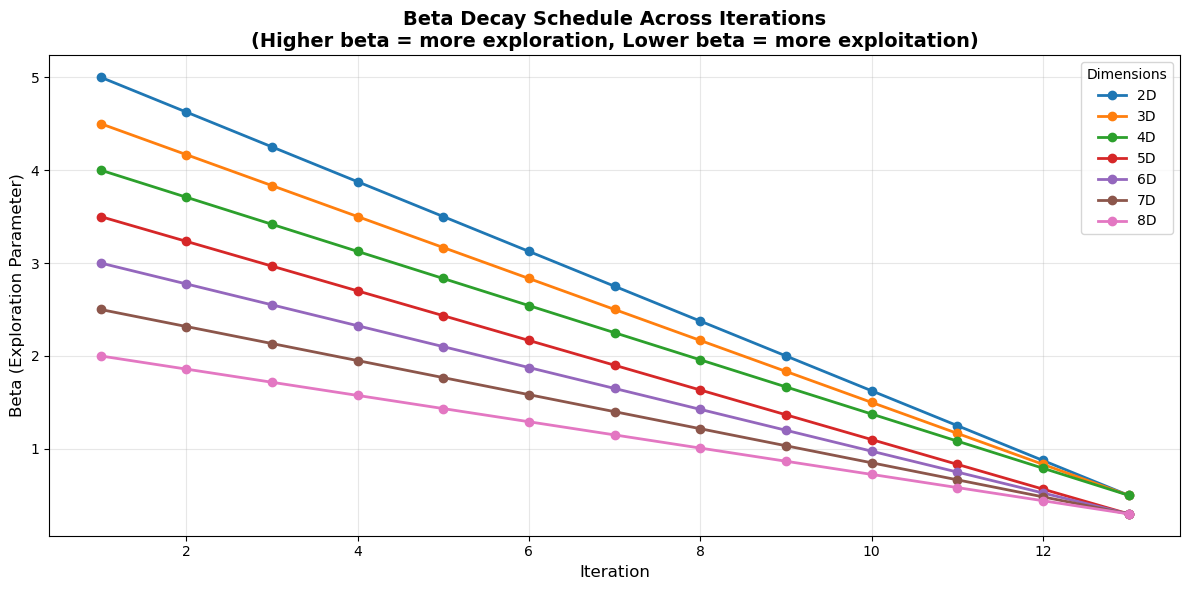

In [5]:
import matplotlib.pyplot as plt

# Configuration
TOTAL_ITERATIONS = 13
DIMENSIONS = [2, 3, 4, 5, 6, 7, 8]  # All dimensions in the problem

def calculate_beta(iteration, n_dims, total_iterations=13):
    """
    Calculate beta (exploration parameter) for UCB acquisition function.
    
    Strategy: 
    - Dimension-dependent starting beta (lower for higher dimensions)
    - Linear decay from high exploration to high exploitation
    - Early iterations: High beta (more exploration)
    - Later iterations: Low beta (more exploitation)
    
    Rationale: Higher dimensional spaces are exponentially larger with sparse data.
    Lower beta prevents over-exploration and focuses on exploitation sooner.
    
    Args:
        iteration: Current iteration number (1-indexed)
        n_dims: Number of dimensions in the problem
        total_iterations: Total number of iterations planned
    
    Returns:
        beta: Exploration parameter for UCB
    """
    # Dimension-dependent beta scaling
    # 2D: starts at 5.0, 8D: starts at 2.0
    # Linear interpolation between dimensions
    if n_dims <= 2:
        beta_start = 5.0
    elif n_dims >= 8:
        beta_start = 2.0
    else:
        # Linear interpolation: 5.0 at 2D → 2.0 at 8D
        beta_start = 5.0 - (5.0 - 2.0) * (n_dims - 2) / (8 - 2)
    
    # End beta is lower for higher dimensions too
    beta_end = 0.5 if n_dims <= 4 else 0.3
    
    # Calculate linear decay over iterations
    beta = beta_start - (beta_start - beta_end) * (iteration - 1) / (total_iterations - 1)
    
    return beta

# Calculate beta schedules for all dimensions
iterations = np.arange(1, TOTAL_ITERATIONS + 1)
beta_schedules = {}

for dim in DIMENSIONS:
    betas = [calculate_beta(it, dim, TOTAL_ITERATIONS) for it in iterations]
    beta_schedules[dim] = betas

# Plot beta schedules
plt.figure(figsize=(12, 6))

for dim in DIMENSIONS:
    plt.plot(iterations, beta_schedules[dim], marker='o', label=f'{dim}D', linewidth=2)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Beta (Exploration Parameter)', fontsize=12)
plt.title('Beta Decay Schedule Across Iterations\n(Higher beta = more exploration, Lower beta = more exploitation)', 
          fontsize=14, fontweight='bold')
plt.legend(title='Dimensions', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Gaussian Process Model & UCB Acquisition Function


In [6]:
class BayesianOptimizer:
    """Bayesian Optimization using Gaussian Process with UCB acquisition
    
    Note: Inputs are already normalized to [0,1] range, no additional normalization needed.
    Uses isotropic kernel (same length scale for all dimensions).
    """
    
    def __init__(self, n_dims):
        self.n_dims = n_dims
        self.gp = None
        
    def fit(self, X, y):
        """Fit Gaussian Process to data"""
        # Length scale bounds (0.1, 5.0) are reasonable for [0,1] normalized inputs
        kernel = C(1.0, (1e-3, 1e3)) * Matern(
            length_scale=0.5,
            length_scale_bounds=(0.1, 5.0),
            nu=2.5
        ) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-1))
        
        # Create and fit GP
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=10,
            normalize_y=True,
            alpha=1e-6
        )
        self.gp.fit(X, y)
        
        return self
    
    def predict(self, X, return_std=True):
        """Predict mean and std for given inputs"""
        return self.gp.predict(X, return_std=return_std)
    
    def ucb_acquisition(self, X, beta=2.0):
        """Upper Confidence Bound acquisition function"""
        mean, std = self.predict(X, return_std=True)
        return mean + beta * std
    
    def suggest_next_point(self, beta=2.0, n_candidates=10000):
        """Suggest next point to sample using UCB (inputs already in [0,1] space)"""
        # Generate random candidates in [0,1] space
        X_candidates = np.random.uniform(0, 1, size=(n_candidates, self.n_dims))
        
        # Calculate UCB for all candidates
        ucb_values = self.ucb_acquisition(X_candidates, beta=beta)
        
        # Select best candidate
        best_idx = np.argmax(ucb_values)
        best_point = X_candidates[best_idx]
        best_ucb = ucb_values[best_idx]
        
        # Also get prediction for this point
        mean, std = self.predict(best_point.reshape(1, -1), return_std=True)
        
        return best_point, best_ucb, mean[0], std[0]


## 4. Beta Calculation


In [7]:
# Beta is now calculated per-function based on its dimensionality
# Preview beta values for this iteration:
print(f"Iteration: {CURRENT_ITERATION}/{TOTAL_ITERATIONS}")
print(f"\nBeta values (dimension-dependent):")
for dim in [2, 3, 4, 5, 6, 7, 8]:
    beta = calculate_beta(CURRENT_ITERATION, n_dims=dim, total_iterations=TOTAL_ITERATIONS)
    strategy = 'EXPLORATION' if beta > 1.5 else 'EXPLOITATION' if beta < 1.0 else 'BALANCED'
    print(f"  {dim}D: β={beta:.3f} ({strategy})")


Iteration: 13/13

Beta values (dimension-dependent):
  2D: β=0.500 (EXPLOITATION)
  3D: β=0.500 (EXPLOITATION)
  4D: β=0.500 (EXPLOITATION)
  5D: β=0.300 (EXPLOITATION)
  6D: β=0.300 (EXPLOITATION)
  7D: β=0.300 (EXPLOITATION)
  8D: β=0.300 (EXPLOITATION)


## 5. Generate Predictions for All Functions


In [8]:
# Generate predictions for all 8 functions
predictions = {}
prediction_details = []

print(f"\n{'='*80}")
print(f"GENERATING PREDICTIONS - ITERATION {CURRENT_ITERATION}")
print(f"{'='*80}\n")

for func_name, data in functions_data.items():
    func_num = int(func_name.split('_')[1])
    
    # Get data (inputs already normalized to [0,1])
    X = data['inputs']
    y = data['outputs']
    n_dims = data['n_dims']
    
    # Calculate beta for this function's dimensionality
    beta = calculate_beta(CURRENT_ITERATION, n_dims=n_dims, total_iterations=TOTAL_ITERATIONS)
    
    # Create and fit optimizer
    optimizer = BayesianOptimizer(n_dims=n_dims)
    optimizer.fit(X, y)
    
    # Suggest next point
    next_point, ucb_val, pred_mean, pred_std = optimizer.suggest_next_point(
        beta=beta, n_candidates=10000
    )
    
    # Store prediction
    predictions[func_name] = next_point
    
    # Store details
    prediction_details.append({
        'Function': func_num,
        'Dimensions': n_dims,
        'Beta': beta,
        'Current Best': data['best_output'],
        'Predicted Mean': pred_mean,
        'Predicted Std': pred_std,
        'UCB Value': ucb_val,
        'Next Point': next_point
    })
    
    print(f"Function {func_num} ({n_dims}D, β={beta:.3f}):")
    print(f"  Current best: {data['best_output']:.4f}")
    print(f"  Predicted: {pred_mean:.4f} ± {pred_std:.4f}")
    print(f"  UCB: {ucb_val:.4f}")
    print(f"  Next point: {next_point}")
    print()

print(f"{'='*80}")
print("✓ Predictions generated for all 8 functions")
print(f"{'='*80}")



GENERATING PREDICTIONS - ITERATION 13

Function 1 (2D, β=0.500):
  Current best: 0.0000
  Predicted: 0.0000 ± 0.0007
  UCB: 0.0004
  Next point: [0.49525503 0.95065016]

Function 2 (2D, β=0.500):
  Current best: 0.6112
  Predicted: 0.5932 ± 0.0828
  UCB: 0.6346
  Next point: [0.6970446  0.97152196]

Function 3 (3D, β=0.500):
  Current best: -0.0234
  Predicted: -0.0183 ± 0.0314
  UCB: -0.0026
  Next point: [0.47582287 0.49240854 0.44027567]

Function 4 (4D, β=0.500):
  Current best: 0.4461
  Predicted: -0.6447 ± 0.6449
  UCB: -0.3223
  Next point: [0.30714351 0.41459783 0.38122413 0.40055006]

Function 5 (4D, β=0.500):
  Current best: 6531.5632
  Predicted: 5244.4182 ± 261.3496
  UCB: 5375.0930
  Next point: [0.85584984 0.97407225 0.94745515 0.96971424]

Function 6 (5D, β=0.300):
  Current best: -0.0783
  Predicted: -0.2609 ± 0.0871
  UCB: -0.2347
  Next point: [0.4406187  0.31922608 0.57910641 0.86773012 0.0728561 ]

Function 7 (6D, β=0.300):
  Current best: 3.0857
  Predicted: 2.593

In [9]:
# === DEBUG: Check data loading and plotting ===
for func_name in ['function_1', 'function_2']:
    data = functions_data[func_name]
    X = data['inputs']
    y = data['outputs']
    initial_count = data['initial_count']
    X_new = X[initial_count:]
    y_new = y[initial_count:]
    print(f"{func_name}: initial_count={initial_count}, total={len(X)}")
    print(f"  New points since initial: {X_new.shape[0]}")
    print(f"  New X: {X_new}")
    print(f"  New y: {y_new}\n")


function_1: initial_count=10, total=22
  New points since initial: 12
  New X: [[0.878378 0.810053]
 [0.37684  0.998705]
 [0.092413 0.657404]
 [0.138847 0.907124]
 [0.298281 0.337724]
 [0.101163 0.176072]
 [0.657488 0.107541]
 [0.875944 0.044838]
 [0.251204 0.540609]
 [0.779712 0.789318]
 [0.612812 0.998175]
 [0.833119 0.708133]]
  New y: [-5.09373756e-067  5.78275789e-140 -9.99250315e-115  1.07876979e-220
 -8.00897719e-017 -6.66487319e-114 -6.50126117e-108 -5.06282337e-243
  4.55278165e-032  2.76662766e-034 -7.53992737e-096  2.11815481e-034]

function_2: initial_count=10, total=22
  New points since initial: 12
  New X: [[0.863288 0.991074]
 [0.5921   0.993016]
 [0.759274 0.842261]
 [0.714623 0.244713]
 [0.791452 0.152693]
 [0.621233 0.232344]
 [0.76441  0.33612 ]
 [0.63514  0.024309]
 [0.732915 0.965513]
 [0.733814 0.930382]
 [0.698069 0.978567]
 [0.701254 0.976166]]
  New y: [0.07814577 0.05242506 0.33316818 0.58928015 0.0865911  0.16050501
 0.19976389 0.25138367 0.56686974 0.301678

## 5b. Visualize 2D Functions (GP Predictions & New Point)

Visualize the Gaussian Process predictions and the suggested new point for 2D functions before submission.

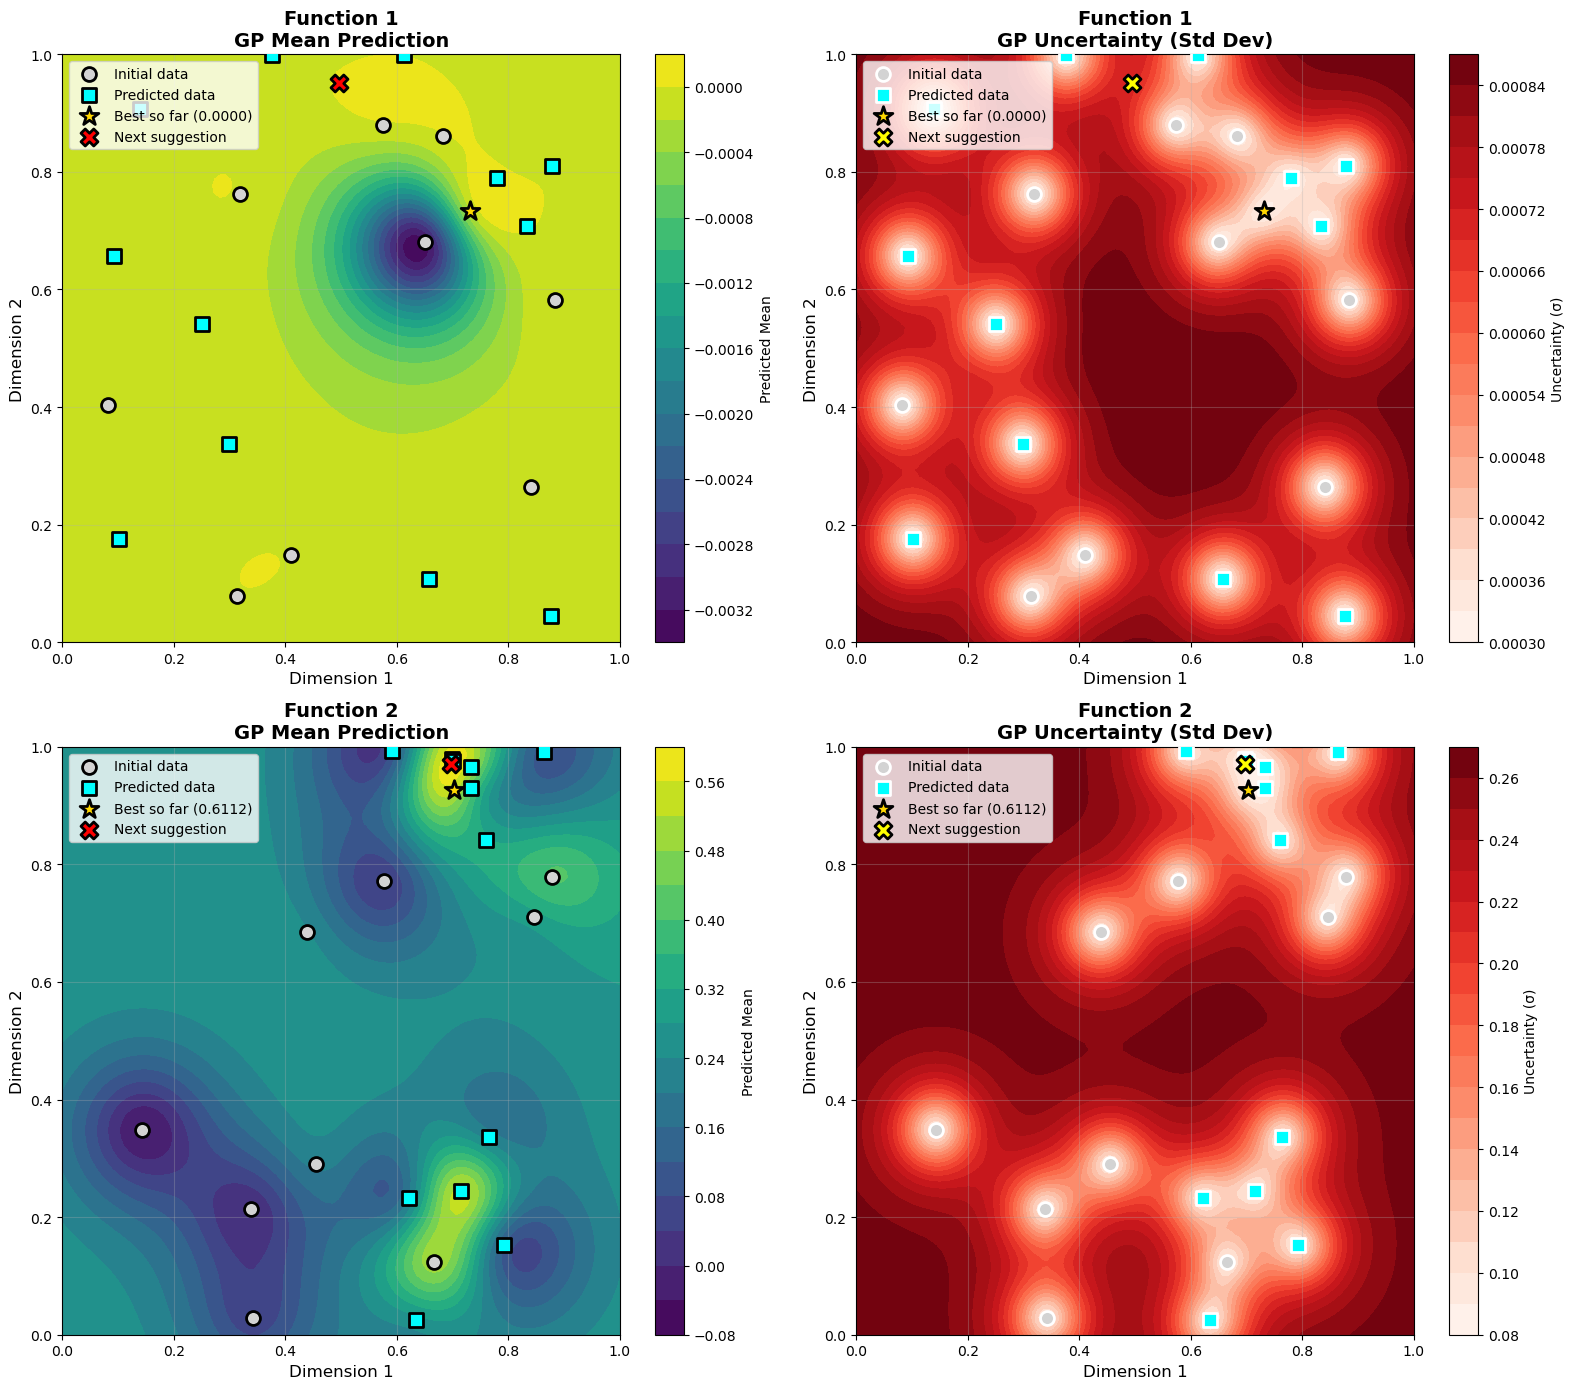

In [10]:
import matplotlib.pyplot as plt

# Visualize 2D functions (function_1 and function_2)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for idx, func_name in enumerate(['function_1', 'function_2']):
    data = functions_data[func_name]
    
    if data['n_dims'] != 2:
        continue
        
    # Get data
    X = data['inputs']
    y = data['outputs']
    initial_count = data['initial_count']
    
    # Fit GP
    optimizer = BayesianOptimizer(n_dims=2)
    optimizer.fit(X, y)
    
    # Create grid for visualization
    n_grid = 100
    x1 = np.linspace(0, 1, n_grid)
    x2 = np.linspace(0, 1, n_grid)
    X1_grid, X2_grid = np.meshgrid(x1, x2)
    X_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
    
    # Get GP predictions (mean and std)
    mean_grid, std_grid = optimizer.predict(X_grid, return_std=True)
    Mean_grid = mean_grid.reshape(n_grid, n_grid)
    Std_grid = std_grid.reshape(n_grid, n_grid)
    
    # Separate initial and new data points
    X_initial = X[:initial_count]
    X_new = X[initial_count:]
    y_initial = y[:initial_count]
    y_new = y[initial_count:]
    
    # Find best point overall
    best_idx = np.argmax(y)
    
    # Plot 1: GP Mean Prediction
    ax1 = axes[idx, 0]
    contour = ax1.contourf(X1_grid, X2_grid, Mean_grid, levels=20, cmap='viridis')
    
    # Plot initial data points (excluding if it's the best)
    initial_mask = np.arange(len(X_initial))
    if best_idx < initial_count:
        initial_mask = initial_mask[initial_mask != best_idx]
    if len(initial_mask) > 0:
        ax1.scatter(X_initial[initial_mask, 0], X_initial[initial_mask, 1], 
                   c='lightgray', s=100, marker='o',
                   edgecolors='black', linewidth=2, zorder=5, label='Initial data')
    
    # Plot new predicted data points (excluding if it's the best)
    if len(X_new) > 0:
        new_mask = np.arange(len(X_new))
        if best_idx >= initial_count:
            new_mask = new_mask[new_mask != (best_idx - initial_count)]
        if len(new_mask) > 0:
            ax1.scatter(X_new[new_mask, 0], X_new[new_mask, 1], 
                       c='cyan', s=100, marker='s',
                       edgecolors='black', linewidth=2, zorder=5, label='Predicted data')
    
    # Highlight best point so far
    ax1.scatter(X[best_idx, 0], X[best_idx, 1], c='gold', s=200, marker='*', 
               edgecolors='black', linewidth=2, zorder=6, label=f'Best so far ({y[best_idx]:.4f})')
    
    # Plot new suggested point
    next_point = predictions[func_name]
    ax1.scatter(next_point[0], next_point[1], c='red', s=150, marker='X', 
               edgecolors='black', linewidth=2, zorder=7, label='Next suggestion')
    
    ax1.set_xlabel('Dimension 1', fontsize=12)
    ax1.set_ylabel('Dimension 2', fontsize=12)
    ax1.set_title(f'{func_name.replace("_", " ").title()}\nGP Mean Prediction', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    plt.colorbar(contour, ax=ax1, label='Predicted Mean')
    
    # Plot 2: GP Uncertainty (Standard Deviation)
    ax2 = axes[idx, 1]
    contour2 = ax2.contourf(X1_grid, X2_grid, Std_grid, levels=20, cmap='Reds')
    
    # Plot initial data points (excluding if it's the best)
    if len(initial_mask) > 0:
        ax2.scatter(X_initial[initial_mask, 0], X_initial[initial_mask, 1], 
                   c='lightgray', s=100, marker='o',
                   edgecolors='white', linewidth=2, zorder=5, label='Initial data')
    
    # Plot new predicted data points (excluding if it's the best)
    if len(X_new) > 0 and len(new_mask) > 0:
        ax2.scatter(X_new[new_mask, 0], X_new[new_mask, 1], 
                   c='cyan', s=100, marker='s',
                   edgecolors='white', linewidth=2, zorder=5, label='Predicted data')
    
    # Plot best point
    ax2.scatter(X[best_idx, 0], X[best_idx, 1], c='gold', s=200, marker='*', 
               edgecolors='black', linewidth=2, zorder=6, label=f'Best so far ({y[best_idx]:.4f})')
    
    # Plot new suggested point
    ax2.scatter(next_point[0], next_point[1], c='yellow', s=150, marker='X', 
               edgecolors='black', linewidth=2, zorder=7, label='Next suggestion')
    
    ax2.set_xlabel('Dimension 1', fontsize=12)
    ax2.set_ylabel('Dimension 2', fontsize=12)
    ax2.set_title(f'{func_name.replace("_", " ").title()}\nGP Uncertainty (Std Dev)', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    plt.colorbar(contour2, ax=ax2, label='Uncertainty (σ)')

plt.tight_layout()
plt.show()


## 6. Format Predictions for Submission

In [11]:
# Create submission array: 8 rows (one per function), max 8 columns (for 8D functions)
submission = np.zeros((8, 8))

for func_name, next_point in predictions.items():
    func_num = int(func_name.split('_')[1]) - 1  # 0-indexed
    n_dims = len(next_point)
    submission[func_num, :n_dims] = next_point

# Save to file
output_dir = Path('../Data/Predictions/Week_1')
output_dir.mkdir(parents=True, exist_ok=True)

# Save as numpy array
np.save(output_dir / f'predictions_iter_{CURRENT_ITERATION}.npy', submission)
print(f"\n✓ Saved predictions to: {output_dir / f'predictions_iter_{CURRENT_ITERATION}.npy'}")

# Also save as CSV for easy viewing
df_submission = pd.DataFrame(submission, 
                              columns=[f'dim_{i+1}' for i in range(8)],
                              index=[f'function_{i+1}' for i in range(8)])
df_submission.to_csv(output_dir / f'predictions_iter_{CURRENT_ITERATION}.csv')
print(f"✓ Saved predictions to: {output_dir / f'predictions_iter_{CURRENT_ITERATION}.csv'}")

# Print formatted predictions for easy copy-paste into black box
print("\n" + "="*80)
print("FORMATTED PREDICTIONS FOR BLACK BOX SUBMISSION")
print("="*80)
print("\nCopy and paste these formatted inputs:\n")

for func_name in sorted(predictions.keys(), key=lambda x: int(x.split('_')[1])):
    func_num = int(func_name.split('_')[1])
    next_point = predictions[func_name]
    n_dims = len(next_point)
    
    # Format each dimension to 6 decimal places and join with dashes
    formatted_input = "-".join([f"{val:.6f}" for val in next_point])
    
    print(f"Function {func_num} ({n_dims}D): {formatted_input}")

print("\n" + "="*80)



✓ Saved predictions to: ../Data/Predictions/Week_1/predictions_iter_13.npy
✓ Saved predictions to: ../Data/Predictions/Week_1/predictions_iter_13.csv

FORMATTED PREDICTIONS FOR BLACK BOX SUBMISSION

Copy and paste these formatted inputs:

Function 1 (2D): 0.495255-0.950650
Function 2 (2D): 0.697045-0.971522
Function 3 (3D): 0.475823-0.492409-0.440276
Function 4 (4D): 0.307144-0.414598-0.381224-0.400550
Function 5 (4D): 0.855850-0.974072-0.947455-0.969714
Function 6 (5D): 0.440619-0.319226-0.579106-0.867730-0.072856
Function 7 (6D): 0.155875-0.119332-0.341476-0.327565-0.417910-0.780389
Function 8 (8D): 0.056428-0.306739-0.064919-0.116708-0.904245-0.493603-0.274629-0.819351



In [12]:
# Display progress summary
summary_data = []

for func_name, data in functions_data.items():
    func_num = int(func_name.split('_')[1])
    n_samples = len(data['outputs'])
    initial_count = data['initial_count']
    new_samples = n_samples - initial_count
    
    summary_data.append({
        'Function': func_num,
        'Dims': data['n_dims'],
        'Initial': initial_count,
        'New': new_samples,
        'Total': n_samples,
        'Best Output': f"{data['best_output']:.4f}",
        'Best Input': data['best_input']
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("OPTIMIZATION PROGRESS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

print(f"\nIterations completed: {max(0, len(data['outputs']) - data['initial_count'])}")
print(f"Current iteration setting: {CURRENT_ITERATION}")

if CURRENT_ITERATION <= TOTAL_ITERATIONS:
    print(f"\nNext iteration beta values (dimension-dependent):")
    for dim in [2, 3, 4, 5, 6, 7, 8]:
        next_beta = calculate_beta(CURRENT_ITERATION, n_dims=dim, total_iterations=TOTAL_ITERATIONS)
        strategy = 'EXPLORATION' if next_beta > 1.5 else 'EXPLOITATION' if next_beta < 1.0 else 'BALANCED'
        print(f"  {dim}D: β={next_beta:.3f} ({strategy})")



OPTIMIZATION PROGRESS SUMMARY
 Function  Dims  Initial  New  Total Best Output                                                                       Best Input
        1     2       10   12     22      0.0000                                         [0.7310236309563586, 0.7329998764152272]
        2     2       10   12     22      0.6112                                         [0.7026365569244406, 0.9265641975455574]
        3     3       15   12     27     -0.0234                                                    [0.446189, 0.399141, 0.53024]
        4     4       30   12     42      0.4461                                           [0.339413, 0.419462, 0.347658, 0.3706]
        5     4       20   12     32   6531.5632                                           [0.913768, 0.9984, 0.994243, 0.963485]
        6     5       20   12     32     -0.0783                               [0.452652, 0.364571, 0.600906, 0.742785, 0.083612]
        7     6       30   12     42      3.0857           

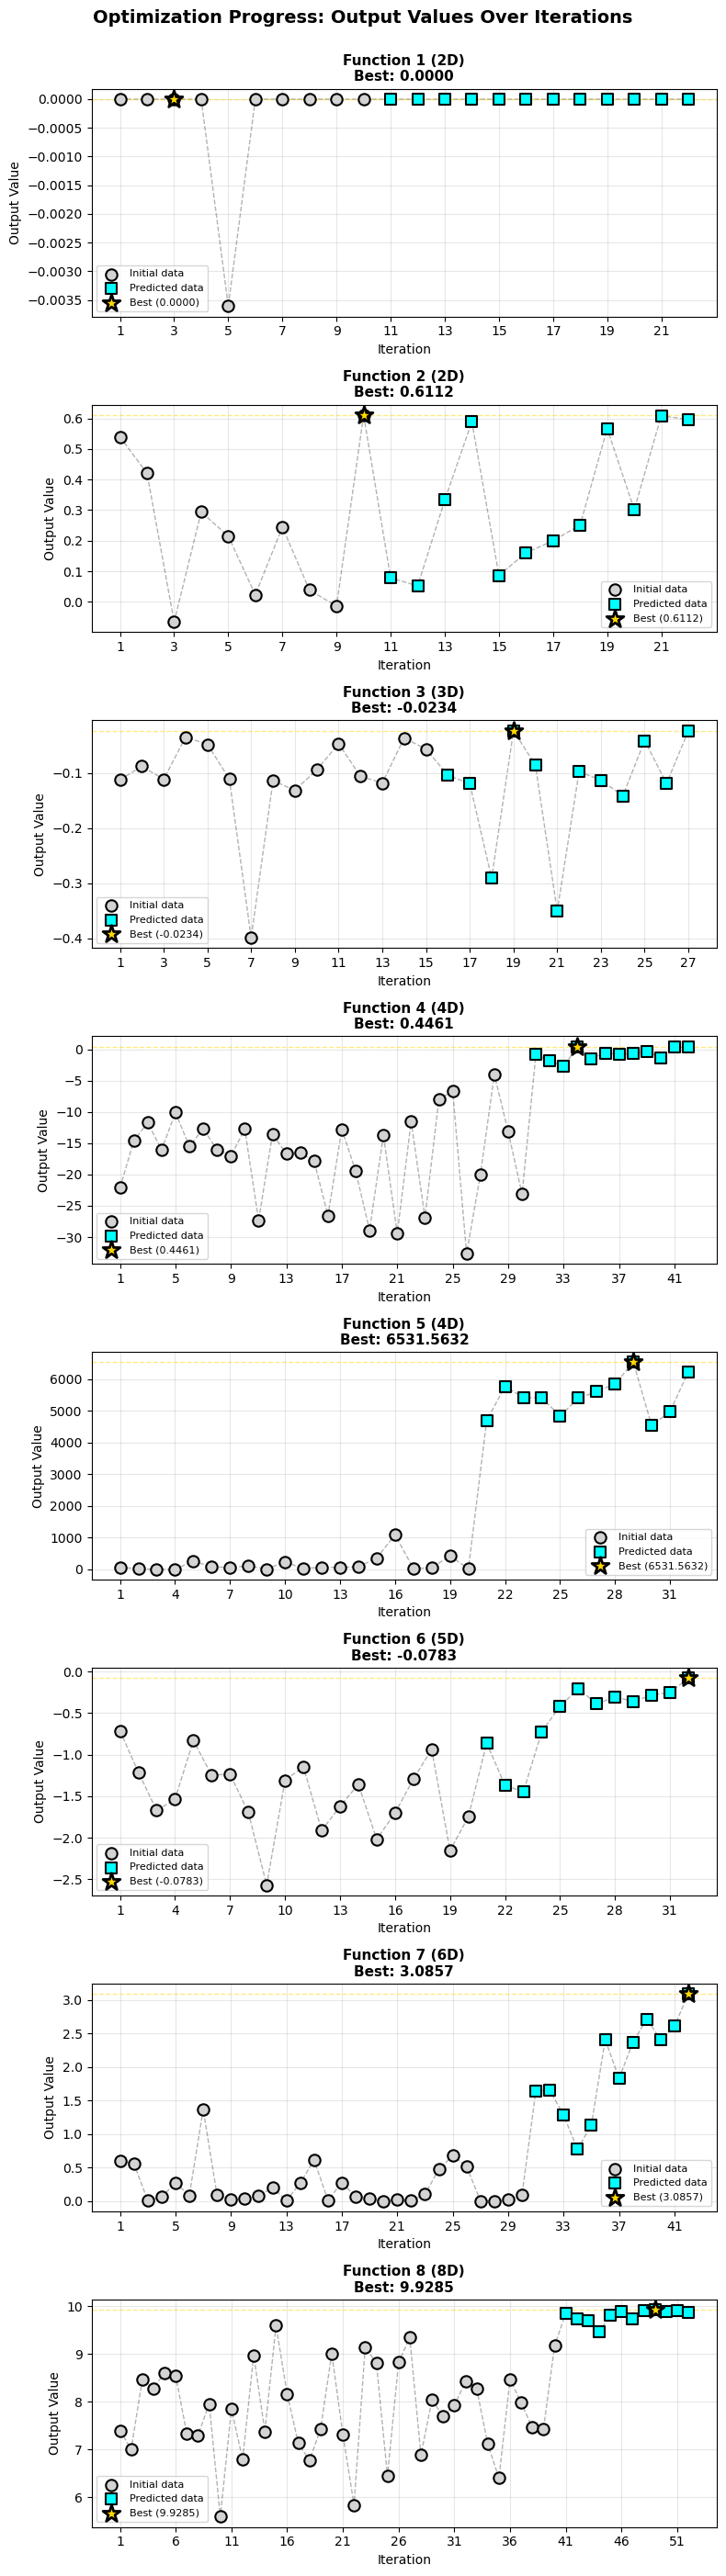


✓ Plotted output progression for all 8 functions


In [13]:
# Visualize output values over iterations for all 8 functions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 1, figsize=(8, 28))
axes = axes.flatten()

for func_idx in range(1, 9):
    func_name = f'function_{func_idx}'
    data = functions_data[func_name]
    
    outputs = data['outputs']
    initial_count = data['initial_count']
    n_samples = len(outputs)
    
    # Create iteration numbers starting from 1
    iterations = list(range(1, n_samples + 1))
    
    # Separate initial and new outputs
    initial_outputs = outputs[:initial_count]
    new_outputs = outputs[initial_count:]
    initial_iters = list(range(1, initial_count + 1))
    new_iters = list(range(initial_count + 1, n_samples + 1))
    
    # Find best output index
    best_idx = np.argmax(outputs)
    best_output = outputs[best_idx]
    
    ax = axes[func_idx - 1]
    
    # Plot initial data points
    ax.scatter(initial_iters, initial_outputs, c='lightgray', s=80, marker='o', 
               edgecolors='black', linewidth=1.5, label='Initial data', zorder=3)
    
    # Plot new predicted data points
    if len(new_outputs) > 0:
        ax.scatter(new_iters, new_outputs, c='cyan', s=80, marker='s', 
                   edgecolors='black', linewidth=1.5, label='Predicted data', zorder=3)
    
    # Highlight the best output
    ax.scatter([best_idx + 1], [best_output], c='gold', s=200, marker='*', 
               edgecolors='black', linewidth=2, label=f'Best ({best_output:.4f})', zorder=4)
    
    # Connect points with a line to show progression
    ax.plot(iterations, outputs, 'k--', alpha=0.3, linewidth=1, zorder=2)
    
    # Add horizontal line at best value
    ax.axhline(y=best_output, color='gold', linestyle='--', alpha=0.5, linewidth=1)
    
    # Labels and title
    ax.set_xlabel('Iteration', fontsize=10)
    ax.set_ylabel('Output Value', fontsize=10)
    ax.set_title(f'Function {func_idx} ({data["n_dims"]}D)\nBest: {best_output:.4f}', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')
    
    # Adjust x-axis to show iteration numbers clearly (starting from 1)
    ax.set_xticks(range(1, n_samples + 1, max(1, n_samples // 10)))

plt.suptitle('Optimization Progress: Output Values Over Iterations', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\n✓ Plotted output progression for all {len(functions_data)} functions")
